# 1. Introduction

Nama  : Muhammad Rafli Febriyanto

Batch : CODA RMT-015

Program ini dibuat untuk mengidentifikasi pola nasabah yang berpotensi keluar dengan meninjau beberapa aspek, yaitu kondisi demografis pelanggan, loyalitas dan pengalaman pelanggan, serta kondisi finansial guna mengetahui segmen nasabah yang paling berisiko keluar dan merancang strategi retensi yang lebih tepat sasaran untuk meningkatkan loyalitas serta profitabilitas jangka panjang.

Dataset : https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn

Tableau : https://public.tableau.com/app/profile/muhammad.rafli.febriyanto/viz/P1M2_Muhamad_Rafli_Febriyanto/Dashboard1?publish=yes

# 2. Identifikasi Masalah

## 2.1 Latar Belakang
Bank XYZ merupakan bank di Eropa yang menyediakan produk dan layanan perbankan seperti tabungan, kartu kredit, dan produk finansial lainnya. Dalam beberapa tahun terakhir, bank XYZ mengalami tingkat customer churn yang berdampak pada jumlah nasabah yang loyal dan penurunan profitabilitas secara keseluruhan. Mengingat biaya memperoleh nasabah baru lebih tinggi dibandingkan mempertahankan nasabah yang sudah ada, maka diperlukan analisis kondisi nasabah yang memiliki potensi besar untuk keluar. Dengan menganalisis data historis nasabah, perusahaan ingin mengidentifikasi pola perilaku dan karakteristik yang berkaitan dengan churn sehingga dapat memberikan strategi yang tepat untuk meningkatkan customer retention.

## 2.2 Kerangka Keja SMART
Mendefinisikan pernyataan masalah menggunakan Kerangka Kerja SMART :

1. Spesific (S) : Mengetahui churn rate dan menentukan segmen nasabah yang berisiko tinggi keluar (churn)
2. Measure (M) : Tingkat churn dapat dianalisis menggunakan persentase *Exited* berdasarkan variabel seperti age, gender, tenure, balance, dan lainnya.
3. Achievable (A) : Masalah dapat dianalisis menggunakan data historis nasabah melalui analisis statistik deskriptif dan inferal untuk mengidentifikasi pola serta hubungan antar variabel terhadap churn.
4. Relevant (R) : Mengidentifikasi faktor utama penyebab churn dapat menghasilkan strategi retensi yang lebih efektif dan meningkatkan profitabilitas jangka panjang.
5. Time-Bound (T) : Hasil analisis perlu diperoleh sebelum kuartal selanjutnya agar strategi retensi nasabah dapat segera diimplementasikan

**Problem Statment**

Bank XYZ ingin mengetahui customer churn rate dan mengidentifikasi pola perilaku nasabah berdasarkan demografis, engagement, dan finansial berdasarkan data historis nasabah sehingga dapat menentukan segmen yang berisiko tinggi dan merancang strategi retensi yang lebih aktif untuk kuartal selanjutnya.


## 2.3 Breaking Down the Problem

**Main Problem**

Bank XYZ belum mengetahui faktor apa saja yang secara signifikan memengaruhi customer churn (demografis, perilaku, dan finansial) serta membantu merancang pengembangan strategis untuk mengurangi churn dan meningkatkan customer retention.

**5W + 1H**
1. Nasabah mana yang memiliki risiko churn yang paling tinggi berdasarkan kondisi demografis ?
2. Seberapa besar jumlah produk / layanan yang dimiliki nasabah mempengaruhi tingkat churn ?
3. Tren churn rate seperti apa yang muncul seiring bertambahnya tenure nasabah ?
4. Apakah nasabah yang mengajukan komplain memiliki kecenderungan churn yang jauh lebih tinggi dibandingkan yang tidak ? 
5. Bagaimana pengaruh nasabah yang keluar terhadap keuntungan bank ? 
6. Apakah status keaktifan nasabah berpengaruh terhadap kemungkinan nasabah melakukan churn / keluar ?

# 3. Data Loading

In [2]:
# Import Library
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt 
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import skew, kurtosis
from scipy.stats import shapiro

In [3]:
df = pd.read_csv('customer-churn.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

Pada dataset ini, terdapat 10000 baris data (entri) dan terdiri dari 18 kolom yang berisikan data historis nasabah Bank XYZ. Pada dataset ini tidak ada null value, tetapi terdapat beberapa jenis data yang tidak sesuai dengan tipe datanya. Terdapat kolom "Row Number" dan "Surname" yang akan dihapus karena tidak digunakan pada analisis ini. 

In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


# 4. Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

**Remove Columns**

In [6]:
# Hapus kolom RowNumber dan Surname
df = df.drop(columns=['RowNumber', 'Surname'])
df.columns

Index(['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score',
       'Card Type', 'Point Earned'],
      dtype='object')

**Missing Values**

In [7]:
# Cek nilai Null pada data
df.isnull().sum()

CustomerId            0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

Tidak ada nilai null pada data ini

**Duplicate Data**

In [8]:
# Cek nilai duplikat
df.duplicated().sum()

np.int64(0)

Tidak ada data duplikat pada data ini

**Inconsistent Data**

In [9]:
# Ubah tipe data kolom 'customer_id'  dari integer menjadi object
df['CustomerId'] = df['CustomerId'].astype('object')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerId          10000 non-null  object 
 1   CreditScore         10000 non-null  int64  
 2   Geography           10000 non-null  object 
 3   Gender              10000 non-null  object 
 4   Age                 10000 non-null  int64  
 5   Tenure              10000 non-null  int64  
 6   Balance             10000 non-null  float64
 7   NumOfProducts       10000 non-null  int64  
 8   HasCrCard           10000 non-null  int64  
 9   IsActiveMember      10000 non-null  int64  
 10  EstimatedSalary     10000 non-null  float64
 11  Exited              10000 non-null  int64  
 12  Complain            10000 non-null  int64  
 13  Satisfaction Score  10000 non-null  int64  
 14  Card Type           10000 non-null  object 
 15  Point Earned        10000 non-null  int64  
dtypes: fl

# 5. Analisis dan Perhitungan

In [10]:
# Menghitung banyaknya nasabah yang sudah keluar (Churn) dan masih stay
# 0 = Stay, 1 = Keluar (Churn)
df['Exited'].value_counts().reset_index(name='Jumlah Nasabah')

,Exited,Jumlah Nasabah
0,0,7962
1,1,2038


Dari 10.000 data historis nasabah, sebanyak 2038 orang nasabah bank sudah keluar `

## 1. Nasabah mana yang memiliki risiko churn yang paling tinggi berdasarkan kondisi demografis ?

In [9]:
# Gender 
df_gender = (
    df.groupby('Gender')
      .agg(
          Total_Customer=('CustomerId', 'count'),
          Total_Churn=('Exited', 'sum'),
          Churn_Rate=('Exited', 'mean')
      )
      .reset_index()
)

df_gender['Churn_Rate'] = df_gender['Churn_Rate'] * 100

df_gender

,Gender,Total_Customer,Total_Churn,Churn_Rate
0,Female,4543,1139,25.071539
1,Male,5457,899,16.474253


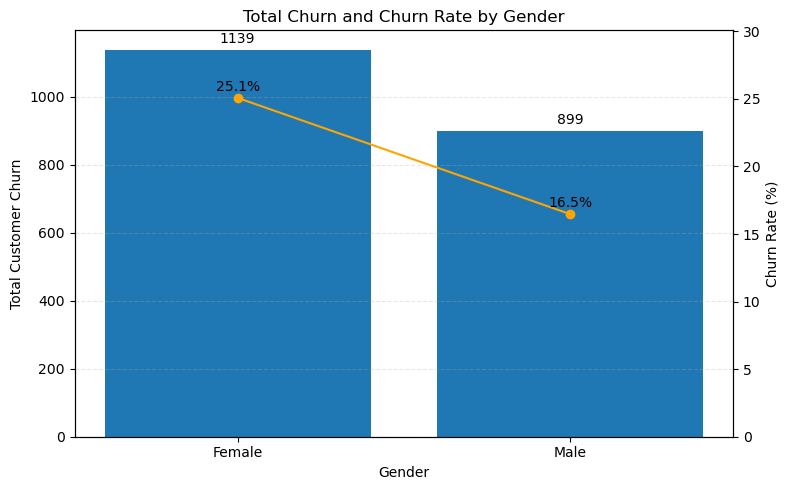

In [12]:
fig, ax1 = plt.subplots(figsize=(8,5))

# Bar Chart
bars = ax1.bar(
  df_gender['Gender'], 
  df_gender['Total_Churn']
)

ax1.set_ylabel('Total Customer Churn')
ax1.set_xlabel('Gender')
ax1.set_title('Total Churn and Churn Rate by Gender')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Line Chart
ax2 = ax1.twinx()

line = ax2.plot(
  df_gender['Gender'], 
  df_gender['Churn_Rate'], 
  marker='o', 
  color='orange'
)

ax2.set_ylabel('Churn Rate (%)')

# Label 

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f'{int(height)}',
        ha='center',
    )


for i, value in enumerate(df_gender['Churn_Rate']):
    ax2.text(
        i,
        value + 0.5,
        f'{value:.1f}%',
        ha='center',
    )
ax2.set_ylim(0, max(df_gender['Churn_Rate']) + 5)
plt.tight_layout()
plt.show()

Perempuan memiliki churn rate jauh lebih tinggi, artinya secara proporsi, nasabah **perempuan lebih rentan meninggalkan bank**. Kemungkinan penyebabnya kemungkinan produk kurang relevan, customer service kurang engaging, atau experience kurang sesuai ekspektasi.

**Rekomendasi**

Melakukan peningkatan marketing untuk meningkatkan retensi nasabah perempuan seperti : 
- Cashback belanja
- Promo lifestyle (fashion, grocery, education)
- Program loyalty khusus perempuan

In [10]:
# Membuat Interval umur
bins = [18, 30, 40, 50, 100]
labels = ['18-30', '31-40', '41-50', '51+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

df_age = (
    df.groupby('AgeGroup')
      .agg(
          Total_Customer=('CustomerId', 'count'),
          Total_Churn=('Exited', 'sum'),
          Churn_Rate=('Exited', 'mean')
      )
      .reset_index()
)

df_age['Churn_Rate'] = df_age['Churn_Rate'] * 100

df_age

C:\Users\M Rafli F\App Data\Local\Temp\ipykernel_17152\873583451.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')


,AgeGroup,Total_Customer,Total_Churn,Churn_Rate
0,18-30,1946,146,7.502569
1,31-40,4451,539,12.109638
2,41-50,2320,788,33.965517
3,51+,1261,563,44.647105


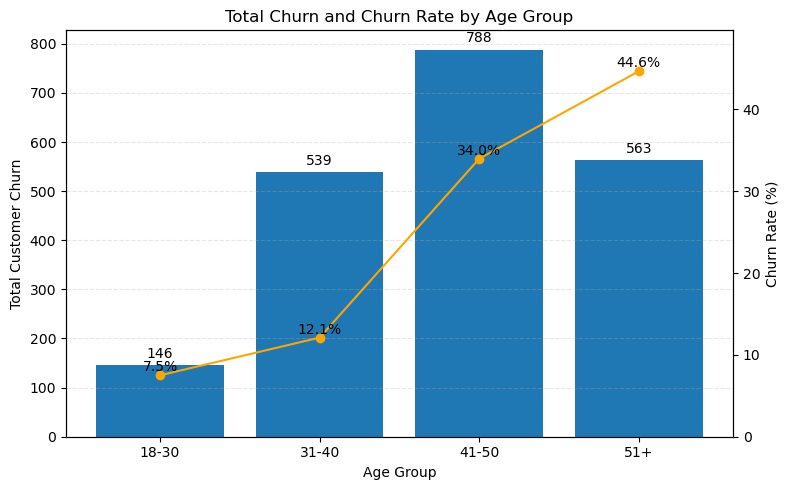

In [14]:
fig, ax1 = plt.subplots(figsize=(8,5))

# Bar Chart
bars = ax1.bar(
  df_age['AgeGroup'], 
  df_age['Total_Churn']
)

ax1.set_ylabel('Total Customer Churn')
ax1.set_xlabel('Age Group')
ax1.set_title('Total Churn and Churn Rate by Age Group')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Line Chart
ax2 = ax1.twinx()

line = ax2.plot(
  df_age['AgeGroup'], 
  df_age['Churn_Rate'], 
  marker='o', 
  color='orange'
)

ax2.set_ylabel('Churn Rate (%)')

# Label 

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 15,
        f'{int(height)}',
        ha='center',
    )


for i, value in enumerate(df_age['Churn_Rate']):
    ax2.text(
        i,
        value + 0.5,
        f'{value:.1f}%',
        ha='center',
    )
ax2.set_ylim(0, max(df_age['Churn_Rate']) + 5)
plt.tight_layout()
plt.show()

Semakin tua usia maka semakin tinggi churn ratenya. **Kelompok usia yang paling berisiko, yaitu umur 41 - 50 (34%) dan 51+ (44.6%)**. Hal ini kemungkinan karena customer usia tua kurang nyaman dengan digital banking dan lebih sensitif terhadap services issues.

**Rekomendasi**
- Mengembangkan produk yang relevan pada usia tua seperti produk pensiun dan wealth managment.
- Melakukan edukasi tutorial penggunaan m-banking.
- Meningkatkan customer assistance atau prioritas untuk nasabah senior.

In [15]:
df_country = (
    df.groupby('Geography')
      .agg(
          Total_Customer=('CustomerId', 'count'),
          Total_Churn=('Exited', 'sum'),
          Churn_Rate=('Exited', 'mean')
      )
      .reset_index()
) 

df_country['Churn_Rate'] = df_country['Churn_Rate'] * 100

df_country

,Geography,Total_Customer,Total_Churn,Churn_Rate
0,France,5014,811,16.174711
1,Germany,2509,814,32.443204
2,Spain,2477,413,16.673395


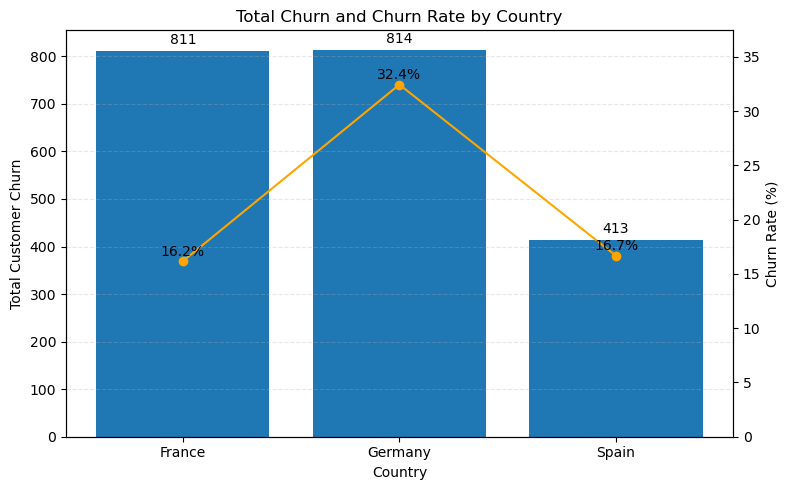

In [16]:
fig, ax1 = plt.subplots(figsize=(8,5))

# Bar Chart
bars = ax1.bar(
  df_country['Geography'], 
  df_country['Total_Churn']
)

ax1.set_ylabel('Total Customer Churn')
ax1.set_xlabel('Country')
ax1.set_title('Total Churn and Churn Rate by Country')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Line Chart
ax2 = ax1.twinx()

line = ax2.plot(
  df_country['Geography'], 
  df_country['Churn_Rate'], 
  marker='o', 
  color='orange'
)

ax2.set_ylabel('Churn Rate (%)')

# Label 

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 15,
        f'{int(height)}',
        ha='center',
    )


for i, value in enumerate(df_country['Churn_Rate']):
    ax2.text(
        i,
        value + 0.5,
        f'{value:.1f}%',
        ha='center',
    )
ax2.set_ylim(0, max(df_country['Churn_Rate']) + 5)
plt.tight_layout()
plt.show()

**Jerman memiliki customer churn rate hampir 2x lebih tinggi (32.54%) dibandingkan spanyol (16.7%) dan Perancis (16.2%)**, sedangkan Spanyol dan Perancis memiliki nilai yang hampir sama. Beberapa kemungkinannya, yaitu bank kompetitor di Jerman lebih agresif, produk kurang sesuai dengan kebutuhan masyarakat Jerman, dan pricing / fee kurang kompetitif. 

**Rekomendasi**

1. Terapkan strategi marketing spesifik untuk Jerman, seperti promo khusus negara Jerman
2. Bandingkan pricing, service quality, atau fitur produk dengan bank lain di Jerman 
3. Analisis penyebab nasabah yang memiliki tingkat komplain yang tinggi.

## 2. Seberapa besar jumlah produk / layanan yang dimiliki nasabah mempengaruhi tingkat churn? ?

**Kartu Kredit**

In [17]:
df_credit = df[df['Exited'] == 1].groupby('HasCrCard').size().reset_index(name='Count')

df_credit['HasCrCard'] = df_credit['HasCrCard'].map({
  0:'Tidak Punya', 
  1: 'Punya'
})

df_credit

,HasCrCard,Count
0,Tidak Punya,613
1,Punya,1425


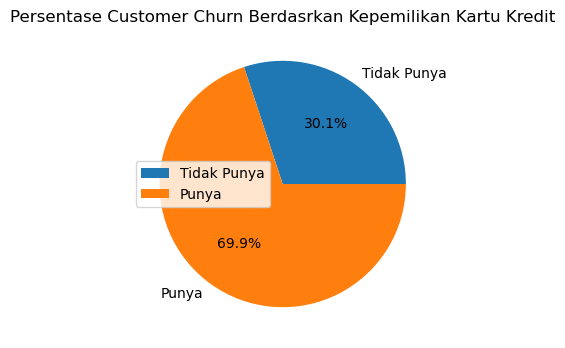

In [18]:
plt.figure(figsize=(4, 4))
plt.pie(df_credit['Count'], labels=df_credit['HasCrCard'], autopct='%1.1f%%')


plt.title('Persentase Customer Churn Berdasrkan Kepemilikan Kartu Kredit')
plt.legend()
plt.show()

Pada hasil analisis tersebut, disimpulkan bahwa ternyata sebesar 69.9% nasabah yang sudah keluar ternyata memiliki kartu kredit. Hal ini tidak sesuai dengan asumsi awal bahwa nasabah yang memiliki produk atau menggunakan banyak layanan cenderung tidak keluar dari bank. Hal ini kemungkinan disebabkan oleh ketidakpuasan terhadap layanan kartu kredit itu sendiri, seperti bunga tinggi, layanan yang kurang responsif, atau benefit yang tidak kompetitif dibanding kompetitor.

**Rekomendasi**

Lakukan evaluasi menyeluruh terhadap produk kartu kredit yang ditawarkan serta identifikasi keluhan spesifik dari nasabah pemegang kartu kredit yang keluar melalui exit survey. 

**Jumlah Produk**

Apakah nasabah yang memiliki banyak produk lebih setia dan tidak rentan keluar ?

In [24]:
df_product_churn = df.copy()
df_product_churn = df.groupby('NumOfProducts')['Exited'].mean().reset_index()

df_product_churn

,NumOfProducts,Exited
0,1,0.277144
1,2,0.076035
2,3,0.827068
3,4,1.000000


In [25]:
df[df['Exited']==1].groupby('NumOfProducts').agg({
  'Complain' : 'sum',
  'CustomerId' : 'count'
}).reset_index()


,NumOfProducts,Complain,CustomerId
0,1,1406,1409
1,2,348,349
2,3,220,220
3,4,60,60


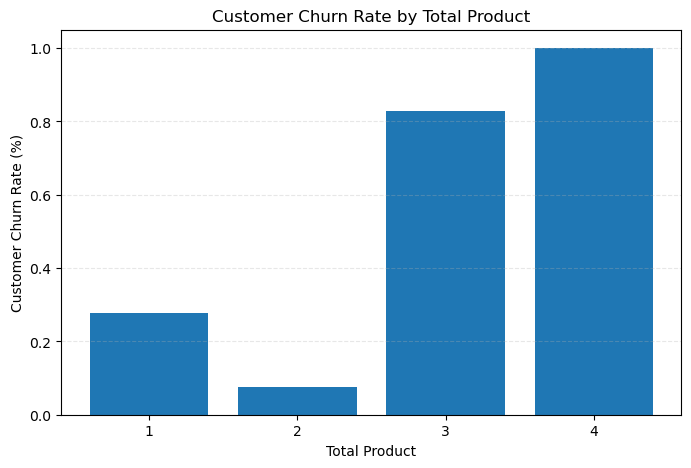

In [23]:
fig, ax1 = plt.subplots(figsize=(8,5))

# Bar Chart
bars = ax1.bar(
  df_product_churn['NumOfProducts'].astype(str), 
  df_product_churn['Exited'] 
)

ax1.set_ylabel('Customer Churn Rate (%)')
ax1.set_xlabel('Total Product')
ax1.set_title('Customer Churn Rate by Total Product')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

Semakin banyak produk yang dimiliki nasabah justru semakin meningkat tinggi risiko terhadap customer churn. **Dari hasil analisis data menunjukkan hampir semua (>80%) nasabah yang memiliki produk > 2 keluar dari bank dan mengajukan komplain**. Hal ini mengindikasikan bahwa memiliki terlalu banyak produk justru menimbulkan beban finansial atau kompleksitas layanan yang tidak sebanding dengan nilai yang dirasakan nasabah.  

**Rekomendasi**

Memastikan setiap layanan dan produk dapat terintegrasikan dengan baik dan memastikan setiap layanan produk memberikan benefit yang nyata bukan sekadar sebagai beban biaya tambahan. Mengadakan program relationship manager khusus dengan nasabah yang punya produk > 2 agar memastikan nasabah mendapatkan pendampingan dan layanan yang lebih personal sehingga menurunkan kompleksitas produk.

## 3. Tren churn rate seperti apa yang muncul seiring bertambahnya tenure nasabah ?

    Tenure    Exited
0        0  0.230024
1        1  0.224155
2        2  0.191794
3        3  0.211100
4        4  0.205258
5        5  0.206522
6        6  0.202689
7        7  0.172179
8        8  0.192195
9        9  0.217480
10      10  0.206122


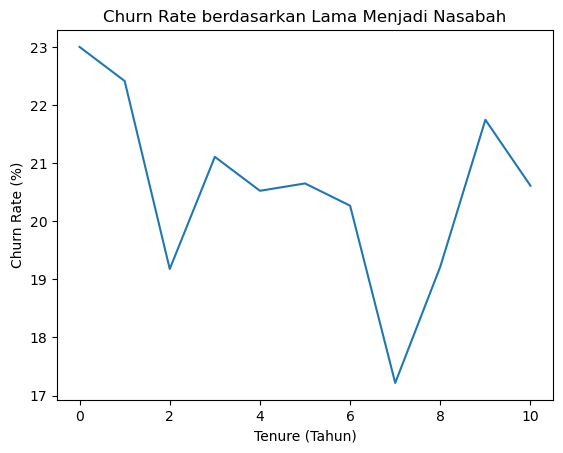

In [37]:
tenure_churn = (
    df.groupby('Tenure')['Exited']
    .mean()
    .reset_index()
)

print(tenure_churn)
# Plot
plt.figure()
plt.plot(tenure_churn['Tenure'], tenure_churn['Exited']*100)
plt.xlabel('Tenure (Tahun)')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate berdasarkan Lama Menjadi Nasabah')
plt.show()

Dari grafik nasabah baru (tenure = 0 - 1 tahun) dan nasabah lama (tenure = 7 - 10 tahun) yang memiliki churn rate sedikit lebih tinggi dibandingkan tahun - tahun lainnya. Pada nasabah baru, tingkat churn kemungkinan disebabkan karena belum terikat loyalitas maupun finansial yang kuat dengan bank. Sementara, pada nasabah lama kemungkinan disebabkan karena mulai merasa jenuh dan tidak mendapatkan manfaat baru atau tidak dihargai setelah menjadi nasabah setia. Namun perlu diperhatikan bahwa tenure buka satu - satunya penyebab customer churn karena perbedaan persentase customer churn yang tidak terlalu jauh setiap tahun. 

**Rekomendasi**

Nasabah baru : Melakukan penguatan program onboarding di 90 hari pertama dengan memberikan promo menarik seperti cashback, bebas biaya admin, atau reward poin agar nasabah bisa langsung merasakan valuenya

Nasabah lama : Melakukan penawaran benefit premium seperti status "Nasabah prioritas" agar mereka merasa dihargai karena loyalitasnya yang cukup lama. 

Tambahan : Identifikasi pola perilaku dan produk yang digunakan nasabah pada tenure 7 tahun karena memiliki churn rate yang paling rendah.

## 4. Apakah nasabah yang mengajukan komplain memiliki kecenderungan churn yang jauh lebih tinggi dibandingkan yang tidak ? 

In [ ]:
# Menghitung Churn Rate Berdasarkan pernah atau tidaknya melakukan komplain
df_complain = df.groupby(['Complain'])['Exited'].agg(['mean', 'sum']).reset_index()
df_complain.columns = ['Complain','Churn Rate','Total Customer Churn']
df_complain

,Complain,Churn Rate,Total Customer Churn
0,0,0.000503,4
1,1,0.995108,2034


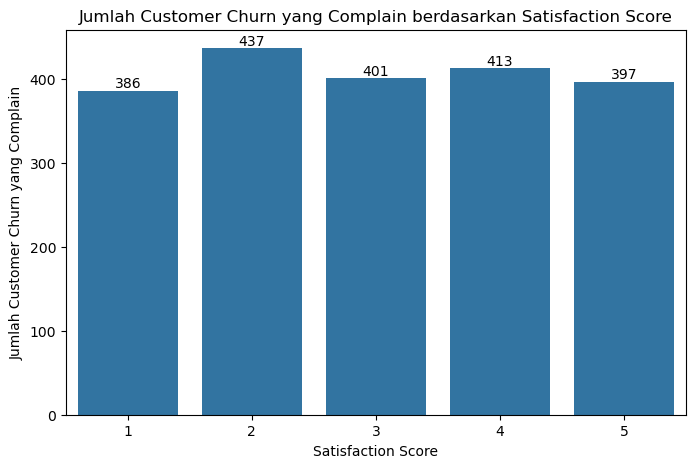

In [44]:
df_churn_complain = df[(df['Exited'] == 1) & (df['Complain'] == 1)]

plt.figure(figsize=(8,5))

ax = sns.countplot(data=df_churn_complain, x='Satisfaction Score')

# Tambahkan label jumlah di atas bar
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,   
        p.get_height(),                  
        int(p.get_height()),             
        ha='center',
        va='bottom'
    )

plt.xlabel('Satisfaction Score')
plt.ylabel('Jumlah Customer Churn yang Complain')
plt.title('Jumlah Customer Churn yang Complain berdasarkan Satisfaction Score')

plt.show()

Hasil analisis menunjukkan bahwa nasabah yang keluar dan pernah mengajukan komplain memiliki churn rate (99.5%) artinya komplain merupakan indikasi awal yang kuat untuk memprediksi nasabah yang keluar. Hasil grafik menunjukkan bahwa tidak bahwa masih terdapat banyak komplain pada nasabah walaupun skor kepuasan pelanggan yang tinggi sehingga skor kepuasan tidak bisa dilihat sebagai faktor untuk menentukan customer churn. 

**Rekomendasi**

Melakukan pengecekan dan peningkatan kualitas pada tim customer service bagaimana mereka menangani keluhan nasabah. Pastikan setiap komplain tidak hanya ditutup (closed), tapi dipastikan pelanggan puas dengan solusinya. Jika terdeteksi ada kegagalan layanan, berikan voucher, diskon, atau poin loyalitas secara otomatis sebelum mereka merasa kecewa.


## 5. Bagaimana pengaruh nasabah yang keluar terhadap keuntungan bank ?

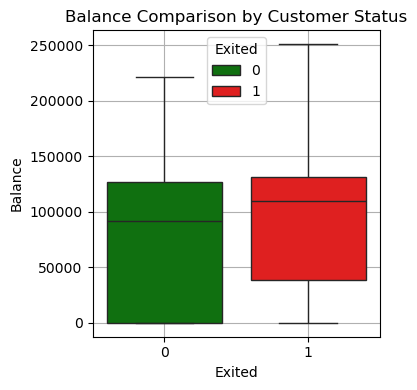

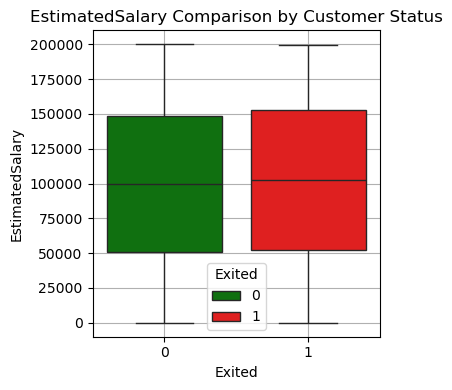

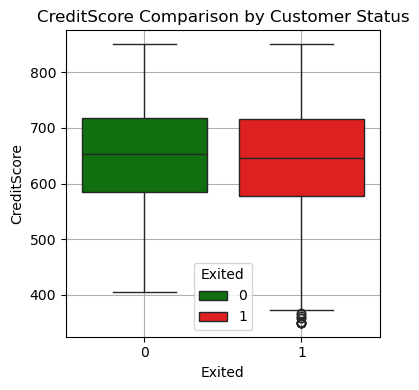

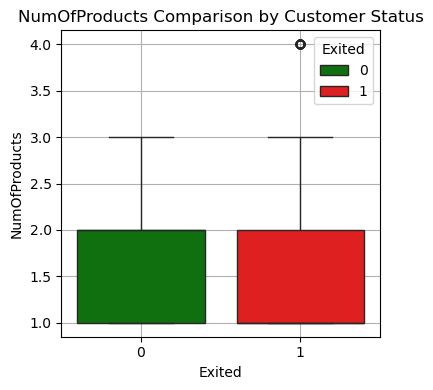

In [94]:
numerical_cols = ['Balance', 'EstimatedSalary', 'CreditScore', 'NumOfProducts']

for col in numerical_cols:
    plt.figure(figsize=(4, 4))
    sns.boxplot(x='Exited', y=col, data=df, hue='Exited', palette={0: 'green', 1: 'red'})
    plt.title(f'{col} Comparison by Customer Status')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [93]:
comparison_table = df.groupby('Exited')[numerical_cols].mean().T
print("Customer Comparison (Exited = 0 vs 1):")
print(comparison_table)

Customer Comparison (Exited = 0 vs 1):
Exited                      0              1
Balance          72742.750663   91109.476006
EstimatedSalary  99726.853141  101509.908783
CreditScore        651.837855     645.414622
NumOfProducts        1.544210       1.475466


Nasabah yang sudah keluar memiliki rata - rata balance yang lebih tinggi (91109.47) dibandingkan nasabah yang bertahan (72742.75). Hal ini mengindikasikan bahwa customer churn dapat berdampak terhadap potensi revenue bank yang berkurang. 

**Rekomendasi**

Melakukan peningkatan strategi marketing pada segmen "High Balance Customer" dalam menjaga retention customer untuk menjaga revenue dari bank. Selain itu, pihak bank dapat membuat layanan premium atau benefit eksklusif pada segmen customer High Balance. 

## 6. Apakah status keaktifan nasabah berpengaruh terhadap kemungkinan nasabah melakukan churn / keluar ?

H0: Tidak terdapat hubungan antara status keaktifan nasabah (IsActiveMember) dan churn (Exited).

H1 : Terdapat hubungan antara status keaktifan nasabah (IsActiveMember) dan churn (Exited).

In [32]:
from scipy.stats import chi2_contingency

# Buat tabel silang
contingency_table = pd.crosstab(df['IsActiveMember'], df['Exited'])

print(contingency_table)

Exited             0     1
IsActiveMember            
0               3546  1303
1               4416   735


In [33]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 243.6948024819593
p-value: 6.153167438113408e-55
Degrees of freedom: 1


C:\Users\M Rafli F\App Data\Local\Temp\ipykernel_17152\1942679161.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(


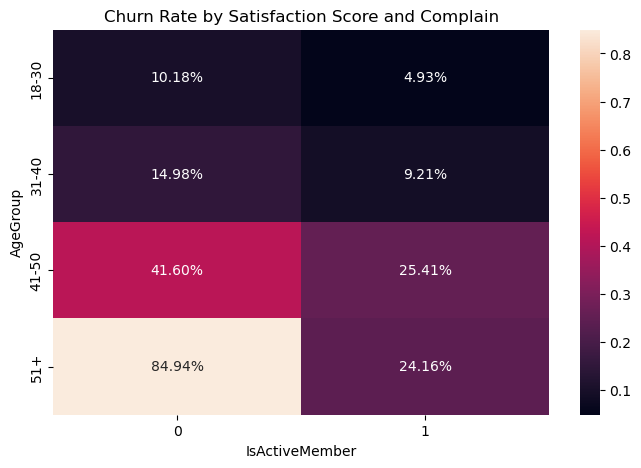

In [ ]:
heatmap_data = df.pivot_table(
    index='AgeGroup',
    columns='IsActiveMember',
    values='Exited',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2%'
)

plt.title('Churn Rate by Age Group and Active Status')
plt.show()

Berdasarkan uji statistik menunjukkan nilai p-value < 0.05 sehingga H0 ditolak, artinya terdapat hubungan antara status keaktifan nasabah dengan status nasabah yang keluar (churn).

Nasabah tidak aktif (0) usia 51+ memiliki churn rate tertinggi sebesar 84.94% — hampir 3.5x lipat dibanding yang aktif (24.16%) di kelompok usia yang sama. Pola konsisten di semua usia — nasabah tidak aktif selalu churn lebih tinggi dibanding yang aktif, dan churn rate meningkat seiring bertambahnya usia. 

**Rekomendasi**

Menjadikan nasabah dengan status tidak aktif sebagai "Early Warning" untuk dasar sistem monitoring churn. Buat reminder penggunaan, notifikasi personal, atau promo akivasi ulang untuk menaikan engagment nasabah yang sudah tidak aktif. 

# 6. Kesimpulan

**Segmentasi berisiko tinggi berdasarkan demografis**

Nasabah yang memiliki segmen gender perempuan, usia lebih dari 41 tahun, dan nasabah yang berlokasi di negara Jerman memiliki churn rate tertinggi sehingga diperlukan strategi retensi berbasis segmentasi. 


**Produk tidak menjamin loyalitas**

Kepemilikan kartu kredit dan nasabah yang memiliki jumlah produk > 2 justru meningkatkan risiko churn sehingga perlu dilakukan evaluasi terkait manfaat, biaya, dan kompleksitas layanan.

**Tenure bukan faktor penentu utama**

Rata - rata churn berdasarkan tenure tidak signifikan secara statistik, tetapi churn sedikit lebih tinggi pada nasabah baru dan nasabah yang sangat lama sehingga diperlukan strategi onboarding dan loyalty program yang berbeda.

**Faktor paling dominan adalah komplain**

Complain menjadi faktor dominan terhadap churn, bahkan pada nasabah dengan skor kepuasan tinggi. Hal ini menunjukkan bahwa penanganan keluhan memiliki peran krusial dalam strategi retensi pelanggan.

**Customer churn berdampak pada revenue**

Nasabah yang keluar memiliki rata - rata balance lebih tinggi sehingga diperlukan pengembangan campaign marketing yang berfokus pada retensi "High balance customer"


**Status keaktifan nasabah**

Berdasarkan uji Chi-Square, terdapat hubungan yang signifikan antara status keaktifan nasabah dengan nasabah yang keluar. Nasabah yang sudah tidak aktif (tidak menggunakan layanan bank cukup lama) dapat menjadi indikasi awal customer churn sehingga nasabah yang tidak aktif dapat dijadikan early warning utama dan perlu sistem monitoring dan reaktivasi engagment